<a href="https://colab.research.google.com/github/mhabibier/scikit-learn-cookbook/blob/main/03_Dimensionality_Reduction_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 — Dimensionality Reduction Techniques

**Nama:** Muhammad Habibie Rabbani  
**Kelas:** TK-47-04  
**Program Studi:** Teknik Komputer, Telkom University

**Referensi utama:** John Sukup, *scikit-learn Cookbook*, edisi ketiga, Packt Publishing (2025), Chapter 3. Kode diadaptasi dari [notebook dan solusi latihan resmi penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_3). Urutan metode dan dataset mengacu pada sumber tersebut; penjelasan bahasa Indonesia serta pemeriksaan tambahan disusun untuk pembelajaran. Lisensi kode sumber terdapat dalam `THIRD_PARTY_NOTICES.md`.

## Tujuan pembelajaran

1. Menjelaskan proyeksi PCA, explained variance, dan pengaruh scaling.
2. Membedakan PCA yang unsupervised dengan LDA yang memakai label.
3. Menggunakan t-SNE sebagai visualisasi struktur lokal secara hati-hati.
4. Membandingkan Logistic Regression dengan dan tanpa PCA menggunakan pipeline dan cross-validation.
5. Membaca visualisasi clustering tanpa menyamakan nomor cluster dengan label kelas.

## Peta reproduksi dan adaptasi

| Resep/latihan sumber | Bagian notebook | Reproduksi dan penyesuaian |
|---|---|---|
| PCA pada Wine | 2–4 | StandardScaler → PCA; scatter, variance, dan rotasi dua fitur |
| LDA dan perbandingan dengan PCA | 5 | Proyeksi Wine dua dimensi; sifat supervised dijelaskan |
| t-SNE pada Digits | 6 | Dataset Digits 8×8, seed tetap; tambahan pemeriksaan perplexity |
| Latihan 1: PCA + Logistic Regression | 7 | Dua pipeline pada Digits; tambahan stratified split, CV, baseline |
| Latihan 2: t-SNE + KMeans | 8 | KMeans pada ruang asli seperti sumber; tambahan ARI |

**Koreksi sumber:** `load_digits()` memuat Digits 8×8, bukan MNIST 28×28. Arah PCA untuk plot dua fitur digambar pada ruang fitur asal yang sesuai. Pernyataan bahwa scaling selalu wajib diganti dengan penjelasan mengenai satuan dan tujuan analisis.

**Cara menjalankan:** buka notebook ini sendiri, lalu jalankan semua sel dari atas ke bawah pada kernel baru. Seluruh dataset chapter ini tersedia dalam scikit-learn atau dibuat secara sintetis, sehingga tidak membutuhkan unduhan data. Angka hasil dapat sedikit berubah antarversi pustaka. Visualisasi seluruh data diberi label sebagai eksplorasi; evaluasi prediktif memakai data test yang terpisah.

## 1. Lingkungan dan reproducibility

Seed mengendalikan pembagian data dan algoritma stokastik. Versi pustaka dicetak supaya hasil bisa ditelusuri. Seed yang sama tidak menjamin hasil identik pada semua perangkat dan versi. Setiap notebook menggunakan nama variabel tersendiri dan tidak bergantung pada eksekusi chapter lain.

In [1]:
%matplotlib inline
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

RANDOM_STATE = 2024
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
COLORS = ["#2563A6", "#D97732", "#47916F", "#885DA6", "#C54B62"]
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__, "| pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__, "| Matplotlib:", matplotlib.__version__)
print("Random state:", RANDOM_STATE)

Python: 3.12.14
NumPy: 2.3.5 | pandas: 2.2.3
scikit-learn: 1.8.0 | Matplotlib: 3.10.8
Random state: 2024


## 2. Mengenal data dan memeriksa kualitasnya

Wine memiliki 178 sampel, 13 fitur kimia numerik, dan tiga kelas. Digits memiliki 1.797 citra digit dengan 64 intensitas piksel (8×8) dan sepuluh kelas. Kedua dataset adalah benchmark kecil. Representativitas terhadap data baru, waktu lain, atau instrumen lain tidak dibuktikan oleh skor benchmark.

Audit memeriksa NaN, nilai tak hingga, duplikasi fitur, fitur konstan, dan distribusi target. Nilai ekstrem tidak langsung dihapus: intensitas piksel dibatasi oleh pengukuran, sementara nilai kimia besar dapat merupakan observasi yang valid. Imputasi/encoding hanya diperlukan bila karakter data memerlukannya.

In [2]:
from sklearn.datasets import load_wine, load_digits
wine = load_wine(as_frame=True)
digits = load_digits()
X_wine, y_wine = wine.data, wine.target
X_digits = pd.DataFrame(digits.data, columns=[f"pixel_{i}" for i in range(64)])
y_digits = pd.Series(digits.target, name="digit")

def audit_table(X, y, label):
    print(label, "shape:", X.shape)
    print("Missing:", int(X.isna().sum().sum()),
          "Infinite:", int(np.isinf(X.to_numpy()).sum()),
          "Duplicate feature rows:", int(X.duplicated().sum()),
          "Constant features:", int((X.nunique() <= 1).sum()))
    print("Class counts:", y.value_counts().sort_index().to_dict())
    assert len(X) == len(y) and np.isfinite(X.to_numpy()).all()

audit_table(X_wine, y_wine, "Wine")
audit_table(X_digits, y_digits, "Digits")
display(X_wine.head())
display(X_wine.describe().loc[["mean", "std", "min", "max"]].round(2))

Wine shape: (178, 13)
Missing: 0 Infinite: 0 Duplicate feature rows: 0 Constant features: 0
Class counts: {0: 59, 1: 71, 2: 48}
Digits shape: (1797, 64)
Missing: 0 Infinite: 0 Duplicate feature rows: 0 Constant features: 3
Class counts: {0: 178, 1: 182, 2: 177, 3: 183, 4: 181, 5: 182, 6: 181, 7: 179, 8: 174, 9: 180}


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


### Analisis audit

Bandingkan rentang kolom Wine: beberapa fitur memiliki skala jauh lebih besar. PCA tanpa scaling bisa didominasi fitur tersebut karena memaksimalkan varians numerik. `StandardScaler` memberi bobot awal yang lebih sebanding ketika satuannya berbeda. Namun scaling juga merupakan pilihan model: bila satuan sudah bermakna dan variasi absolut harus dipertahankan, standardisasi belum tentu tepat. Kolom piksel konstan pada Digits tidak otomatis merupakan kesalahan; StandardScaler dapat menanganinya tanpa membagi dengan nol.

## 3. PCA: proyeksi yang mempertahankan varians

Untuk matriks terpusat $X_c$, PCA mencari arah ortonormal $W_k$ agar proyeksi $Z=X_cW_k$ mempertahankan variasi sebanyak mungkin. Arah tersebut dapat dihitung dengan SVD atau eigendecomposition matriks kovarians. Bila eigenvalue berurutan adalah $\lambda_1,\ldots,\lambda_p$, proporsi varians komponen ke-$j$ adalah:

$$r_j=\frac{\lambda_j}{\sum_{\ell=1}^{p}\lambda_\ell}.$$

PCA **tidak memakai target**. Varians tinggi belum tentu merupakan informasi paling berguna untuk klasifikasi. `n_components=2` cocok untuk scatter plot, sementara ambang seperti `0.95` memilih jumlah komponen berdasarkan proporsi varians. PCA scikit-learn melakukan centering tetapi tidak otomatis melakukan standardisasi.

### Reproduksi PCA dua dimensi pada Wine

Proyeksi seluruh Wine berikut merupakan eksplorasi seperti contoh buku. Label hanya digunakan untuk memberi warna setelah proyeksi; plot ini bukan pengujian generalisasi model.

Original shape: (178, 13) → projected: (178, 2)
Explained variance ratio: [0.362  0.1921]
Total variance retained: 0.5541


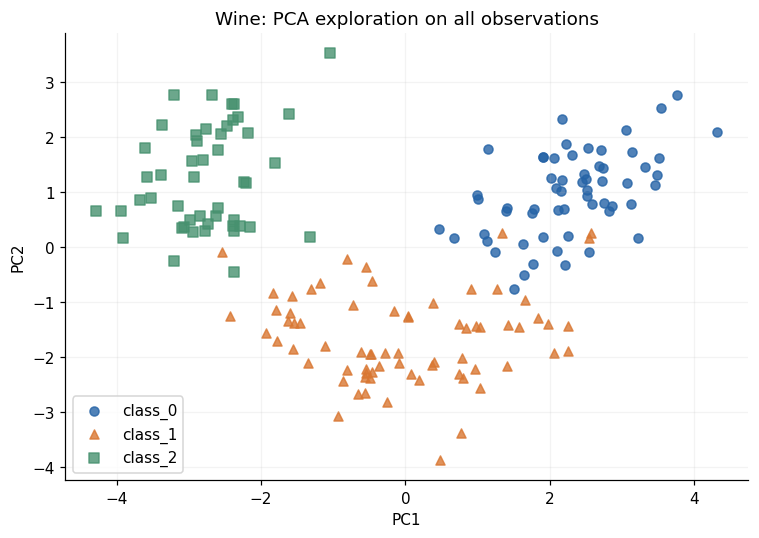

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, svd_solver="full")),
])
Z_pca = pca_pipeline.fit_transform(X_wine)
pca = pca_pipeline.named_steps["pca"]
print("Original shape:", X_wine.shape, "→ projected:", Z_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(4))
print("Total variance retained:", round(pca.explained_variance_ratio_.sum(), 4))

fig, ax = plt.subplots(figsize=(7, 5))
for i, marker in enumerate(["o", "^", "s"]):
    mask = y_wine.to_numpy() == i
    ax.scatter(Z_pca[mask, 0], Z_pca[mask, 1], color=COLORS[i],
               marker=marker, s=35, alpha=0.8, label=wine.target_names[i])
ax.set(xlabel="PC1", ylabel="PC2", title="Wine: PCA exploration on all observations")
ax.legend(); ax.grid(alpha=0.15)
plt.tight_layout(); plt.show()

Orthonormal components: True


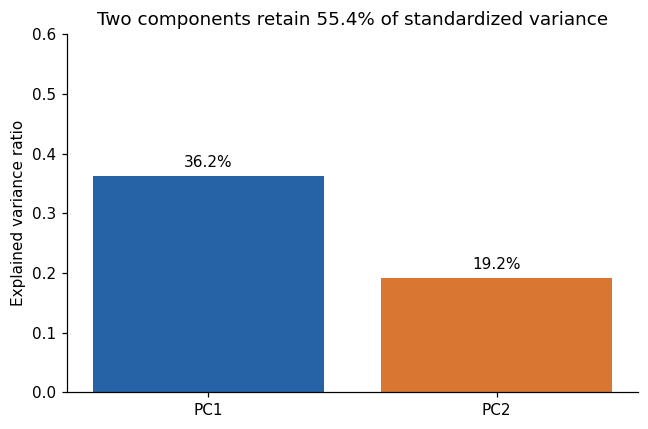

,PC1 weight,PC2 weight
alcohol,0.144,0.484
malic_acid,-0.245,0.225
ash,-0.002,0.316
alcalinity_of_ash,-0.239,-0.011
magnesium,0.142,0.300
total_phenols,0.395,0.065
flavanoids,0.423,-0.003
nonflavanoid_phenols,-0.299,0.029
proanthocyanins,0.313,0.039
color_intensity,-0.089,0.530


In [4]:
ratios = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["PC1", "PC2"], ratios, color=COLORS[:2])
ax.bar_label(bars, labels=[f"{v:.1%}" for v in ratios], padding=4)
ax.set(ylim=(0, 0.6), ylabel="Explained variance ratio",
       title=f"Two components retain {ratios.sum():.1%} of standardized variance")
plt.tight_layout(); plt.show()

# Bobot masing-masing fitur asli pada dua arah PCA.
component_weights = pd.DataFrame(pca.components_.T, index=X_wine.columns,
                                 columns=["PC1 weight", "PC2 weight"])
display(component_weights.round(3))
print("Orthonormal components:",
      np.allclose(pca.components_ @ pca.components_.T, np.eye(2)))

### Interpretasi PCA

Dua komponen mengompres 13 fitur menjadi dua angka per sampel. Total explained variance pada output mengukur variasi fitur yang dipertahankan, **bukan persentase akurasi klasifikasi**. Bobot komponen menyatakan kombinasi linear fitur terstandar. Tanda satu komponen dapat terbalik pada implementasi lain tanpa mengubah geometri proyeksi. Bobot besar tidak membuktikan bahwa suatu fitur menyebabkan kelas tertentu.

Untuk menentukan jumlah komponen, kurva kumulatif membantu menilai kehilangan informasi. Bila PCA dipakai dalam prediksi, jumlah komponennya harus ditetapkan dari training/CV, bukan dari skor test.

Components for ≥95% standardized variance (exploration): 10
Reconstruction MSE on standardized features: 0.4459


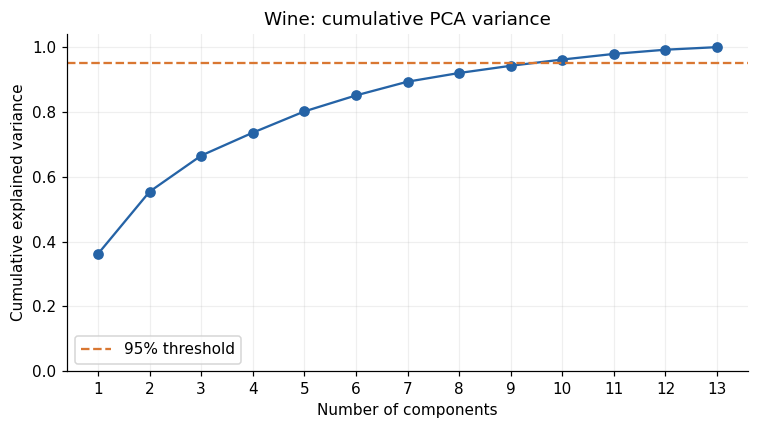

In [5]:
Z_standard = pca_pipeline.named_steps["scaler"].transform(X_wine)
full_pca = PCA(svd_solver="full").fit(Z_standard)
cumulative_ratio = np.cumsum(full_pca.explained_variance_ratio_)
components_95 = int(np.searchsorted(cumulative_ratio, 0.95) + 1)
print("Components for ≥95% standardized variance (exploration):", components_95)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, 14), cumulative_ratio, marker="o", color=COLORS[0])
ax.axhline(0.95, color=COLORS[1], linestyle="--", label="95% threshold")
ax.set(xlabel="Number of components", ylabel="Cumulative explained variance",
       title="Wine: cumulative PCA variance", xticks=np.arange(1, 14), ylim=(0, 1.04))
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

# Rekonstruksi dari dua komponen pada skala standar.
reconstructed = pca.inverse_transform(Z_pca)
print("Reconstruction MSE on standardized features:",
      round(float(np.mean((Z_standard - reconstructed)**2)), 4))

## 4. Rotasi dua fitur: memahami geometri PCA

Resep buku membandingkan dua pasangan fitur sebelum dan setelah PCA. Bila dua fitur diproyeksikan menjadi **dua** komponen, tidak ada dimensi yang dibuang; yang terlihat adalah perubahan basis/rotasi (hingga perubahan tanda). Karena itu, pemisahan visual yang tampak lebih mudah tidak otomatis berarti informasi klasifikasi bertambah.

Panah berikut digambar di ruang dua fitur terstandar menggunakan vektor komponen yang sesuai. Bobot dua fitur pertama dari PCA 13 dimensi tidak boleh langsung dianggap panah PC1/PC2 pada scatter skor PCA.

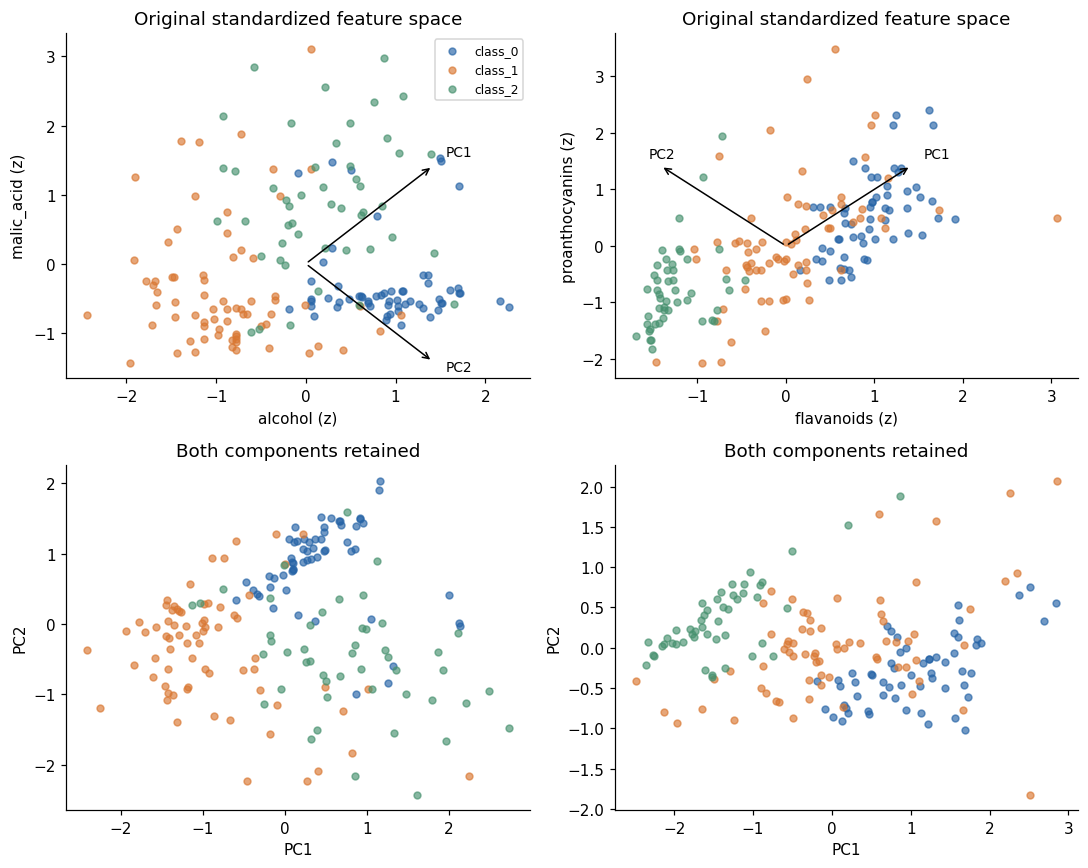

In [6]:
pairs = [("alcohol", "malic_acid"), ("flavanoids", "proanthocyanins")]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col, pair in enumerate(pairs):
    scaled_pair = StandardScaler().fit_transform(X_wine[list(pair)])
    pair_pca = PCA(n_components=2, svd_solver="full")
    rotated_pair = pair_pca.fit_transform(scaled_pair)
    for i in range(3):
        mask = y_wine.to_numpy() == i
        axes[0, col].scatter(*scaled_pair[mask].T, s=20, color=COLORS[i],
                            alpha=0.65, label=wine.target_names[i])
        axes[1, col].scatter(*rotated_pair[mask].T, s=20, color=COLORS[i], alpha=0.65)
    for j, direction in enumerate(pair_pca.components_):
        arrow = direction * 2
        axes[0, col].annotate("", xy=arrow, xytext=(0, 0),
                             arrowprops={"arrowstyle":"->", "color":"black"})
        axes[0, col].text(*(arrow * 1.1), f"PC{j+1}", fontsize=9)
    axes[0, col].set(xlabel=f"{pair[0]} (z)", ylabel=f"{pair[1]} (z)",
                      title="Original standardized feature space")
    axes[1, col].set(xlabel="PC1", ylabel="PC2", title="Both components retained")
    assert np.allclose(pair_pca.inverse_transform(rotated_pair), scaled_pair)
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Linear Discriminant Analysis (LDA)

LDA menggunakan label untuk mencari proyeksi yang memperbesar perbedaan antarkelas relatif terhadap penyebaran di dalam kelas. Untuk satu arah $w$, gagasan kriterianya adalah:

$$J(w)=\frac{w^T S_Bw}{w^T S_Ww},$$

dengan $S_B$ mengukur scatter antarkelas dan $S_W$ scatter dalam kelas. Jumlah arah diskriminan paling banyak $min(p,C-1)$. Wine mempunyai tiga kelas sehingga maksimum dua arah.

Sebagai classifier generatif, LDA memodelkan fitur dalam tiap kelas dengan distribusi Gaussian dan matriks kovarians bersama. Penyimpangan asumsi bisa menurunkan kinerja, tetapi tidak berarti algoritma pasti gagal. Scaling biasanya penting bagi PCA; untuk LDA ideal, perubahan skala linear yang invertibel tidak mengubah informasi diskriminan, walaupun scaling dapat membantu kondisi numerik. Pipeline di sini dipertahankan mengikuti buku.

LDA shape: (178, 2)
Maximum LDA components: 2
Discriminant explained variance ratio: [0.6875 0.3125]


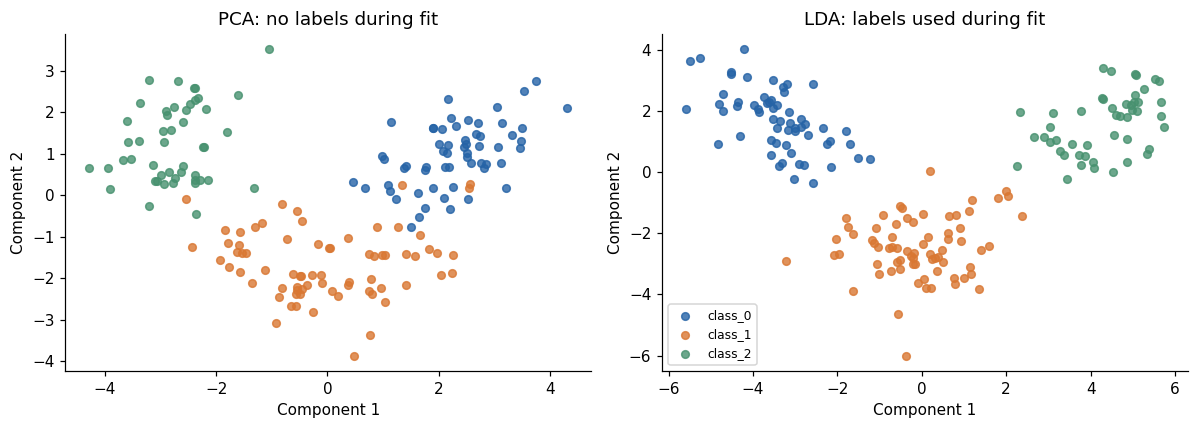

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(n_components=2)),
])
Z_lda = lda_pipeline.fit_transform(X_wine, y_wine)
print("LDA shape:", Z_lda.shape)
print("Maximum LDA components:", min(X_wine.shape[1], y_wine.nunique()-1))
print("Discriminant explained variance ratio:",
      lda_pipeline.named_steps["lda"].explained_variance_ratio_.round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, Z, title in zip(axes, [Z_pca, Z_lda], ["PCA: no labels during fit", "LDA: labels used during fit"]):
    for i in range(3):
        mask = y_wine.to_numpy() == i
        ax.scatter(Z[mask, 0], Z[mask, 1], s=25, color=COLORS[i],
                   label=wine.target_names[i], alpha=0.8)
    ax.set(xlabel="Component 1", ylabel="Component 2", title=title)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Interpretasi PCA vs LDA

LDA memang dibentuk dengan bantuan label, sehingga pemisahan kelas pada data yang dipakai saat `fit` dapat terlihat lebih jelas. Plot eksploratif ini tidak membuktikan LDA mengungguli PCA pada data baru. Explained variance LDA menggambarkan arah diskriminan dan tidak identik dengan proporsi varians seluruh fitur pada PCA. Untuk evaluasi klasifikasi LDA, letakkan scaler dan LDA di pipeline, lalu fit hanya pada training tiap fold.

## 6. t-SNE untuk visualisasi Digits

Digunakan **Digits bawaan scikit-learn (8×8)**. t-SNE membentuk probabilitas kedekatan antarobservasi pada ruang asal dan ruang proyeksi, lalu meminimalkan divergensi KL. Distribusi Student-t pada proyeksi membantu menempatkan kelompok lokal. Optimisasinya nonkonveks sehingga hasil bergantung pada inisialisasi, seed, dan hyperparameter.

`perplexity` mengendalikan skala lingkungan lokal dan harus lebih kecil daripada jumlah sampel. Sumbu t-SNE tidak memiliki arti fitur tertentu. Jarak antarkelompok, luas kelompok, serta ruang kosong pada plot tidak boleh dianggap ukuran kuantitatif kelas. scikit-learn `TSNE` menyediakan `fit_transform()` tetapi tidak `transform()` untuk sampel baru; karena itu pipeline t-SNE di bawah dipakai untuk visualisasi dataset yang sama.

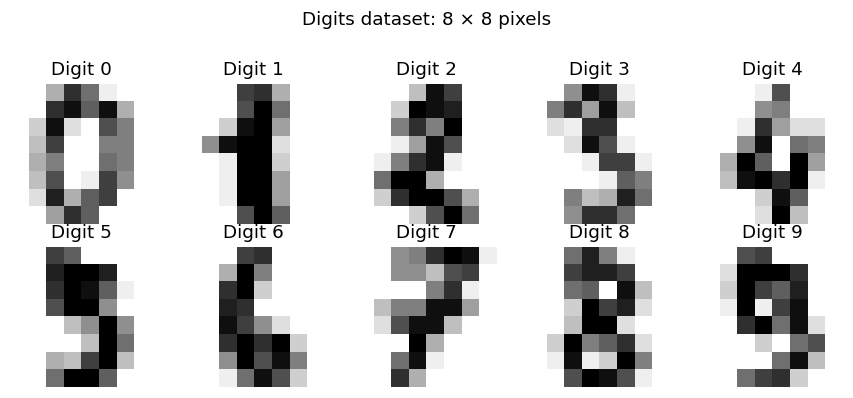

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for ax, image, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(f"Digit {label}"); ax.axis("off")
fig.suptitle("Digits dataset: 8 × 8 pixels", y=1.02)
plt.tight_layout(); plt.show()

t-SNE shape: (1797, 2)
Trustworthiness (10 neighbors): 0.9863
KL divergence: 0.8369


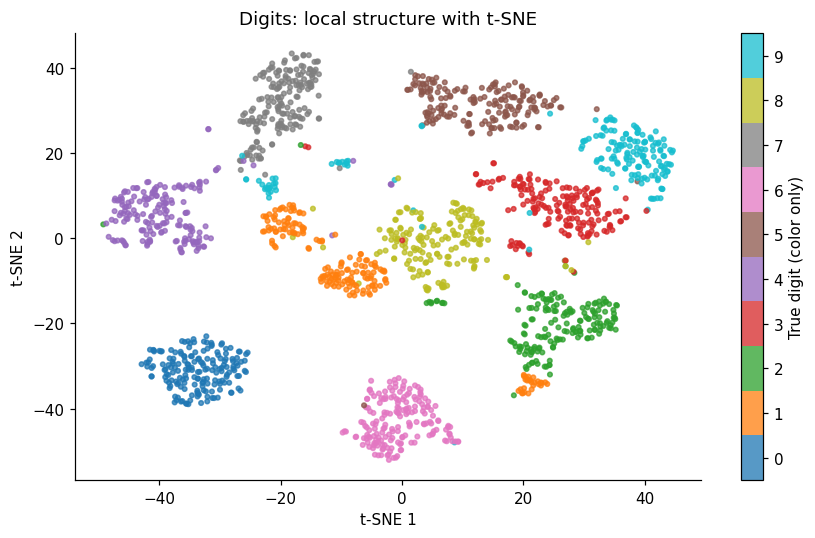

In [9]:
from sklearn.manifold import TSNE, trustworthiness

tsne_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("tsne", TSNE(n_components=2, perplexity=30, max_iter=1000,
                   init="pca", learning_rate="auto", random_state=RANDOM_STATE)),
])
Z_tsne = tsne_pipeline.fit_transform(X_digits)
X_digits_scaled = tsne_pipeline.named_steps["scaler"].transform(X_digits)
local_trust = trustworthiness(X_digits_scaled, Z_tsne, n_neighbors=10)
print("t-SNE shape:", Z_tsne.shape)
print("Trustworthiness (10 neighbors):", round(local_trust, 4))
print("KL divergence:", round(tsne_pipeline.named_steps["tsne"].kl_divergence_, 4))
assert Z_tsne.shape == (len(X_digits), 2) and np.isfinite(Z_tsne).all()
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=y_digits, cmap="tab10",
                     vmin=-0.5, vmax=9.5, s=9, alpha=0.75)
fig.colorbar(scatter, ax=ax, ticks=range(10), label="True digit (color only)")
ax.set(xlabel="t-SNE 1", ylabel="t-SNE 2", title="Digits: local structure with t-SNE")
plt.tight_layout(); plt.show()

### Interpretasi dan sensitivitas t-SNE

Trustworthiness berada antara 0 dan 1; nilai besar berarti sedikit tetangga palsu yang muncul di proyeksi menurut jumlah tetangga yang dipilih. Metrik ini bukan akurasi klasifikasi. KL divergence merupakan nilai objective optimisasi dan tidak digunakan untuk menentukan jumlah kelas.

Sebagai tambahan, jalankan satu perplexity berbeda dengan seed yang sama. Bandingkan lingkungan lokal, bukan arah atau posisi absolut plot. Tidak ada model klasifikasi yang dipilih dari plot ini.

Trustworthiness for perplexity=50: 0.9858


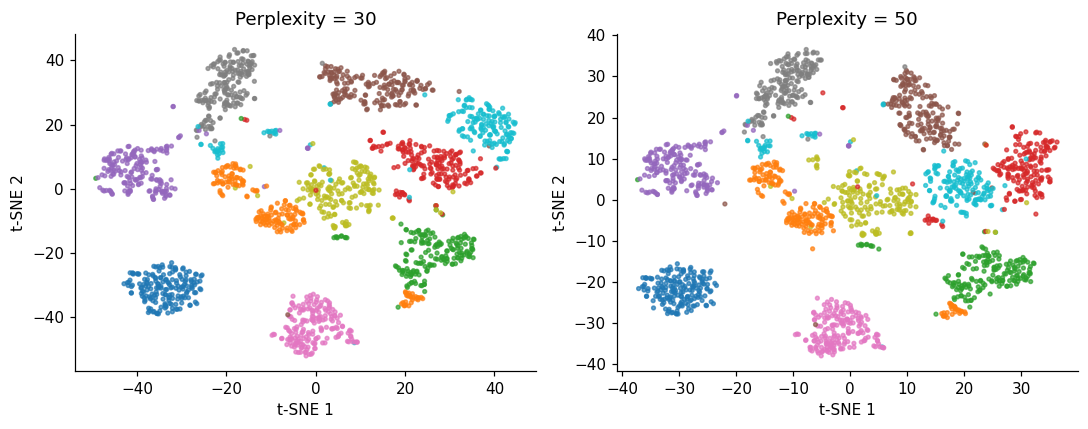

In [10]:
Z_tsne_50 = TSNE(n_components=2, perplexity=50, max_iter=1000,
                  init="pca", learning_rate="auto", random_state=RANDOM_STATE).fit_transform(X_digits_scaled)
print("Trustworthiness for perplexity=50:",
      round(trustworthiness(X_digits_scaled, Z_tsne_50, n_neighbors=10), 4))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, Z, value in zip(axes, [Z_tsne, Z_tsne_50], [30, 50]):
    ax.scatter(*Z.T, c=y_digits, cmap="tab10", vmin=-0.5, vmax=9.5, s=6, alpha=0.7)
    ax.set(title=f"Perplexity = {value}", xlabel="t-SNE 1", ylabel="t-SNE 2")
plt.tight_layout(); plt.show()

## 7. Latihan 1 — Logistic Regression dengan dan tanpa PCA

Dua pipeline ditetapkan sebelum test dibuka: StandardScaler → LogisticRegression dan StandardScaler → PCA (95% varians) → LogisticRegression. Split 80:20 memakai stratifikasi agar setiap digit terwakili. Cross-validation lima fold hanya berlangsung pada training. Scaler dan PCA di-fit ulang di setiap fold, sehingga informasi dari validation tidak digunakan saat transformasi dipelajari.

Skor utama pemilihan adalah mean accuracy CV. Macro-F1 pada test memberi bobot sama untuk setiap kelas. Baseline `DummyClassifier(strategy="most_frequent")` selalu memilih kelas training terbanyak. Test dipakai setelah semua konfigurasi ditetapkan; selisih kecil pada satu split tidak cukup untuk klaim universal bahwa PCA lebih baik.

In [11]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=RANDOM_STATE, stratify=y_digits)
assert set(X_train.index).isdisjoint(X_test.index)
print("Training:", X_train.shape, "| test:", X_test.shape)
models = {
    "Logistic, 64 features": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000)),
    ]),
    "PCA 95% + Logistic": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, svd_solver="full")),
        ("model", LogisticRegression(max_iter=5000)),
    ]),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_rows.append({"model":name, "CV accuracy mean":scores.mean(),
                    "CV std":scores.std()})
cv_results = pd.DataFrame(cv_rows)
selected_name = cv_results.loc[cv_results["CV accuracy mean"].idxmax(), "model"]
display(cv_results.round(4))
print("Selected using training CV:", selected_name)

Training: (1437, 64) | test: (360, 64)
Selected using training CV: Logistic, 64 features


,model,CV accuracy mean,CV std
0,"Logistic, 64 features",0.9680,0.0099
1,PCA 95% + Logistic,0.9617,0.0174


PCA retained variance on training: 0.9511


,model,test accuracy,test macro-F1,features after preprocessing
0,"Logistic, 64 features",0.9694,0.9694,64
1,PCA 95% + Logistic,0.9639,0.9637,40
2,Most-frequent baseline,0.1028,0.0186,0


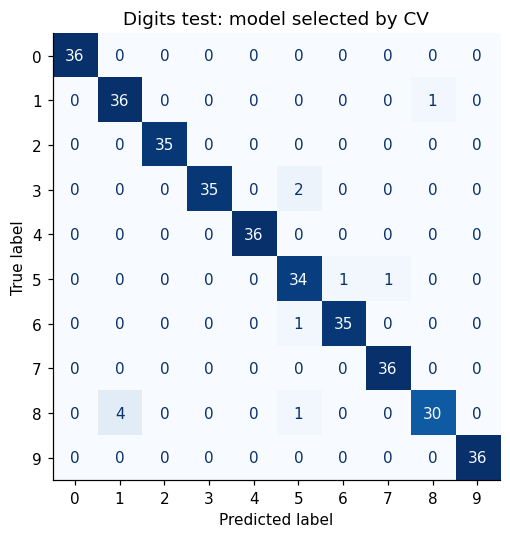

In [12]:
test_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    test_rows.append({"model":name, "test accuracy":accuracy_score(y_test, pred),
                      "test macro-F1":f1_score(y_test, pred, average="macro"),
                      "features after preprocessing":
                          model.named_steps["pca"].n_components_ if "pca" in model.named_steps else X_train.shape[1]})
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
test_rows.append({"model":"Most-frequent baseline", "test accuracy":accuracy_score(y_test, dummy_pred),
                  "test macro-F1":f1_score(y_test, dummy_pred, average="macro"),
                  "features after preprocessing":0})
test_results = pd.DataFrame(test_rows)
display(test_results.round(4))
print("PCA retained variance on training:",
      round(models["PCA 95% + Logistic"].named_steps["pca"].explained_variance_ratio_.sum(), 4))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(models[selected_name], X_test, y_test,
                                     ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Digits test: model selected by CV")
plt.tight_layout(); plt.show()

### Analisis latihan klasifikasi

Baca jumlah komponen yang dipilih dari training: PCA mengurangi dimensi, tetapi jumlahnya tidak harus dua. Bandingkan CV mean dan variasinya sebelum melihat test. Skor kedua pipeline di atas baseline menunjukkan bahwa fitur memiliki informasi prediktif dalam benchmark ini. Bila skor PCA turun sedikit, itu merupakan pertukaran antara kompresi dan informasi yang hilang, bukan error program.

Confusion matrix dihitung pada model yang dipilih **sebelum** melihat test. Baris menunjukkan digit sebenarnya dan kolom digit prediksi. Nilai di luar diagonal menjelaskan digit mana yang masih tertukar. CV std adalah variasi antar-fold, bukan confidence interval formal.

## 8. Latihan 2 — KMeans pada visualisasi t-SNE

Seperti solusi resmi, KMeans dilatih pada **64 piksel asli**, sedangkan posisi scatter berasal dari t-SNE atas piksel yang distandardisasi. Dua geometri ini tidak identik dan dipertahankan sebagai reproduksi yang diberi catatan. `n_clusters=10` ditetapkan karena latihan memakai sepuluh digit; jumlah itu tidak ditemukan secara otomatis.

Nomor cluster bersifat arbitrer: cluster 0 tidak harus berarti digit 0. Adjusted Rand Index (ARI) membandingkan pasangan observasi tanpa memerlukan penyamaan nomor cluster dengan label. ARI=1 berarti dua pembagian identik, sekitar 0 berarti setara harapan acak, dan nilai negatif mungkin terjadi. Ini evaluasi deskriptif terhadap label yang tersedia, bukan akurasi model pada sampel baru.

KMeans on original pixel space — ARI: 0.6699


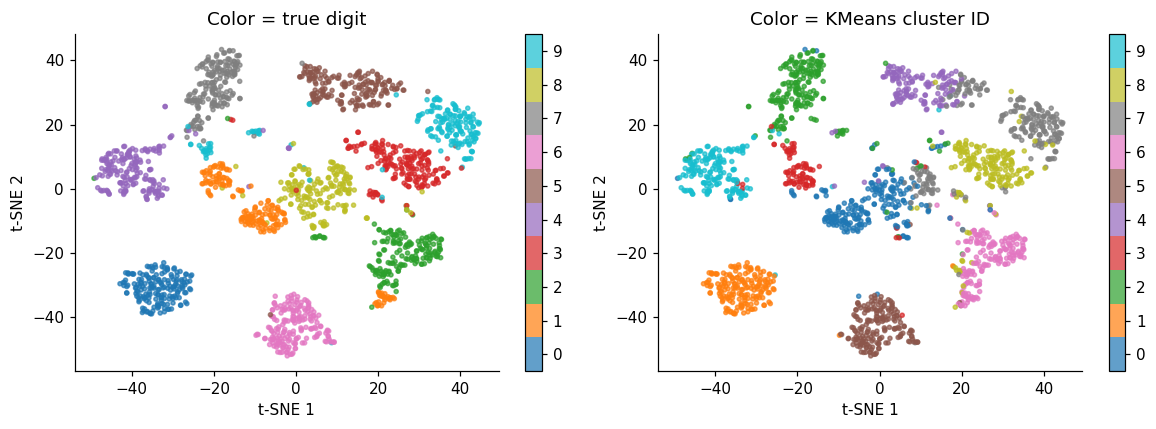

Cluster ID,0,1,2,3,4,5,6,7,8,9
True digit,,,,,,,,,,
0,0,177,0,0,0,0,0,0,0,1
1,99,0,0,55,1,2,24,0,1,0
2,8,1,3,2,0,0,148,2,13,0
3,7,0,7,0,2,0,1,9,157,0
4,4,0,8,3,0,0,0,0,0,166
5,0,0,0,0,130,1,0,47,2,2
6,2,1,0,1,0,177,0,0,0,0
7,2,0,177,0,0,0,0,0,0,0
8,102,0,5,6,4,2,3,50,2,0


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
kmeans = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_digits)
ari = adjusted_rand_score(y_digits, cluster_labels)
print("KMeans on original pixel space — ARI:", round(ari, 4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, labels, title in zip(axes, [y_digits, cluster_labels],
                            ["Color = true digit", "Color = KMeans cluster ID"]):
    scatter = ax.scatter(*Z_tsne.T, c=labels, cmap="tab10", vmin=-0.5, vmax=9.5, s=7, alpha=0.7)
    ax.set(title=title, xlabel="t-SNE 1", ylabel="t-SNE 2")
    fig.colorbar(scatter, ax=ax, ticks=range(10))
plt.tight_layout(); plt.show()
display(pd.crosstab(pd.Series(y_digits.to_numpy(), name="True digit"),
                    pd.Series(cluster_labels, name="Cluster ID")))

## Catatan hasil eksekusi

Pada eksekusi yang disertakan (4 Oktober 2026), PCA dua komponen pada Wine mempertahankan sekitar **55,41%** varians; 95% memerlukan 10 komponen. Pada Digits, Logistic Regression tanpa PCA memperoleh akurasi test **96,94%**, sedangkan pipeline PCA 95% memperoleh **96,39%** dengan 40 komponen. Selisih kecil pada satu split belum membuktikan keunggulan universal. Model dipilih dengan CV training, bukan skor test. ARI KMeans sekitar **0,670** menunjukkan kecocokan parsial dengan label digit; cluster bukan label kelas.

Perbedaan versi pustaka dapat menghasilkan sedikit perubahan angka.

### Analisis clustering

Gunakan crosstab dan ARI untuk melihat apakah satu digit tersebar ke beberapa cluster atau beberapa digit berbagi cluster. Kesamaan warna antarpanel tidak menunjukkan cluster yang sama. Pengelompokan pada plot t-SNE dapat tampak tegas walaupun KMeans pada ruang asli belum memisahkan label dengan sempurna. KMeans memakai asumsi kelompok yang cocok dengan geometri jarak Euclidean; bentuk digit yang beragam dapat melanggar gambaran kelompok sederhana tersebut.

## 9. Ringkasan chapter

| Metode | Memakai label saat fit? | Tujuan | Dapat mentransformasi data baru? | Batasan |
|---|---|---|---|---|
| PCA | Tidak | Mempertahankan varians melalui proyeksi linear | Ya | Varians belum tentu relevan bagi target |
| LDA | Ya | Memperbesar pemisahan antarkelas | Ya | Maksimum C−1 komponen; asumsi kelas/kovarians |
| t-SNE | Tidak | Menampilkan lingkungan lokal secara nonlinier | Tidak pada implementasi sklearn | Sumbu dan jarak global sulit ditafsirkan |
| KMeans | Tidak | Mengelompokkan berdasarkan jarak ke centroid | Menetapkan cluster baru melalui predict | ID cluster tidak sama dengan kelas |

**Kesimpulan:** reduksi dimensi harus dipilih sesuai tujuan. PCA cocok untuk kompresi linear, LDA membutuhkan label, dan t-SNE berguna untuk eksplorasi lokal. Penampilan plot dan proporsi varians tidak menggantikan evaluasi prediksi. Dalam latihan klasifikasi, pipeline lengkap di dalam CV menjaga pemisahan training dan validation; test dipakai setelah konfigurasi ditetapkan.

### Pertanyaan refleksi

1. Mengapa explained variance 95% tidak berarti accuracy 95%?
2. Mengapa Wine hanya menyediakan paling banyak dua arah LDA?
3. Mengapa nomor cluster tidak boleh langsung dibandingkan dengan nomor digit sebagai accuracy?
4. Apa risiko memilih jumlah komponen dengan mencoba berkali-kali pada test set?

## 10. Referensi

1. John Sukup, *scikit-learn Cookbook*, 3rd ed., Packt, 2025, Chapter 3.
2. [Notebook dan exercise solution resmi](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/main/Chapter_3).
3. [scikit-learn: PCA](https://scikit-learn.org/stable/modules/decomposition.html#pca), [LDA](https://scikit-learn.org/stable/modules/lda_qda.html), dan [t-SNE](https://scikit-learn.org/stable/modules/manifold.html#t-sne).
4. [Digits dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html), [trustworthiness](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.trustworthiness.html), dan [ARI](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html).
5. [Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html).

Kode merupakan reproduksi/adaptasi beratribusi; teori dan analisis merupakan parafrasa untuk tugas. Bantuan LLM digunakan untuk menyusun penjelasan serta memeriksa kode. Mahasiswa perlu membaca hasil, memahami alasan setiap penyesuaian, dan menulis refleksinya sendiri sesuai ketentuan kelas.